# CIS & VCG Project
# Naive Bayes-Based Classification of Handwritten Gurmukhi Characters

**Objective:** Explore a public handwritten Gurmukhi character dataset, preprocess images, prepare image features, train a Naive Bayes classifier, classify unseen samples, and evaluate the model using standard metrics and a confusion matrix.


## Step 1 — Install dependencies
 It installs the libraries used throughout the project.


# DATASET USED FOR THIS RUN

This version uses a publicly accessible Gurmukhi handwritten numeral dataset hosted in a public GitHub repository.

**Dataset download ZIP:** https://github.com/siddharthapramanik771/Gurmukhi-Handwritten-Digit-Classification/archive/refs/heads/main.zip

This is an isolated handwritten Gurmukhi **character-symbol** classification dataset (numeral characters), used here. The public repository documents the dataset structure and its use for Gurmukhi handwritten digit classification.


In [1]:
# Download the public dataset automatically
import os, zipfile, shutil, requests
from pathlib import Path

DATASET_URL = "https://github.com/siddharthapramanik771/Gurmukhi-Handwritten-Digit-Classification/archive/refs/heads/main.zip"
DOWNLOAD_ZIP = "/content/gurmukhi_dataset.zip"

print("Downloading dataset...")
r = requests.get(DATASET_URL, timeout=120)
r.raise_for_status()
Path(DOWNLOAD_ZIP).write_bytes(r.content)

extract_dir = Path("/content/gurmukhi_dataset_repo")
if extract_dir.exists():
    shutil.rmtree(extract_dir)

with zipfile.ZipFile(DOWNLOAD_ZIP, "r") as z:
    z.extractall(extract_dir)

# Locate the repository root automatically
repo_roots = [p for p in extract_dir.iterdir() if p.is_dir()]
REPO_ROOT = repo_roots[0] if repo_roots else extract_dir

print("Dataset downloaded and extracted.")
print("Dataset root:", REPO_ROOT)
print("Contents:", [p.name for p in REPO_ROOT.iterdir()])


Dataset downloaded and extracted.
Dataset root: /content/gurmukhi_dataset_repo/Gurmukhi-Handwritten-Digit-Classification-Building-neural-network-from-scratch--main
Contents: ['README.md', 'backwardprop.png', 'Gurmukhi_Handwritten_Digit_Classification.ipynb', 'nnarchitechture.png', 'fordwardprop.png', 'handwritten_data']


In [2]:
!pip -q install scikit-image seaborn joblib pillow tqdm

## Step 2 — Import libraries

In [3]:
import os, zipfile, shutil, random, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageOps
from google.colab import files

from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE = Path("/content/gurmukhi_project")
RAW = BASE / "data" / "raw"
OUT = BASE / "outputs"
MODEL_DIR = BASE / "models"

for p in [RAW, OUT, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project directory:", BASE)


Project directory: /content/gurmukhi_project


## Step 3 — Get the public dataset


In [4]:
# Dataset is downloaded automatically in the previous cell. No manual upload is required.
print('Using downloaded dataset at:', REPO_ROOT)


Using downloaded dataset at: /content/gurmukhi_dataset_repo/Gurmukhi-Handwritten-Digit-Classification-Building-neural-network-from-scratch--main


In [5]:
# Adapt the downloaded train/test dataset to the project loader format
from pathlib import Path
import os, shutil

# The source repository uses:
#   handwritten_data/train/<class>/*.png
#   handwritten_data/test/<class>/*.png
SOURCE_DATA = REPO_ROOT / "handwritten_data"

if not SOURCE_DATA.exists():
    # fallback: find handwritten_data recursively
    matches = list(REPO_ROOT.rglob("handwritten_data"))
    if matches:
        SOURCE_DATA = matches[0]

assert SOURCE_DATA.exists(), f"Could not find handwritten_data under {REPO_ROOT}"

PROJECT_RAW = Path("/content/data/raw/gurmukhi")
if PROJECT_RAW.exists():
    shutil.rmtree(PROJECT_RAW)
PROJECT_RAW.mkdir(parents=True, exist_ok=True)

# Combine train and test images into one labeled pool.
# Filenames are made unique so no files overwrite each other.
for split in ["train", "test"]:
    split_dir = SOURCE_DATA / split
    if not split_dir.exists():
        continue
    for class_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
        out_dir = PROJECT_RAW / class_dir.name
        out_dir.mkdir(parents=True, exist_ok=True)
        for i, img in enumerate(sorted(class_dir.glob("*"))):
            if img.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}:
                shutil.copy2(img, out_dir / f"{split}_{i}_{img.name}")

print("Prepared labeled dataset at:", PROJECT_RAW)
print("Classes:", sorted([p.name for p in PROJECT_RAW.iterdir() if p.is_dir()]))


Prepared labeled dataset at: /content/data/raw/gurmukhi
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## Step 4 — Discover images and inspect dataset

In [8]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

def discover_class_folders(root):
    folders = []
    for d in sorted(root.rglob("*")):
        if d.is_dir() and any(
            p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
            for p in d.iterdir()
        ):
            folders.append(d)
    return folders

class_folders = discover_class_folders(PROJECT_RAW)
print("Class folders found:", len(class_folders))

records = []
for folder in class_folders:
    imgs = sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )
    records.extend([(str(p), folder.name) for p in imgs])

df = pd.DataFrame(records, columns=["path", "label"])

if df.empty:
    raise ValueError("No images were found. Check the ZIP structure.")

print("Total images:", len(df))
print("Number of classes:", df["label"].nunique())
display(df.head())

Class folders found: 10
Total images: 1000
Number of classes: 10


,path,label
0,/content/data/raw/gurmukhi/0/train_0_1.bmp,0
1,/content/data/raw/gurmukhi/0/train_10_18.bmp,0
2,/content/data/raw/gurmukhi/0/train_11_19.bmp,0
3,/content/data/raw/gurmukhi/0/train_12_2.bmp,0
4,/content/data/raw/gurmukhi/0/train_13_20.bmp,0


## Step 5 — Dataset class distribution

,label,image_count
0,0,100
1,1,100
2,2,100
3,3,100
4,4,100
5,5,100
6,6,100
7,7,100
8,8,100
9,9,100


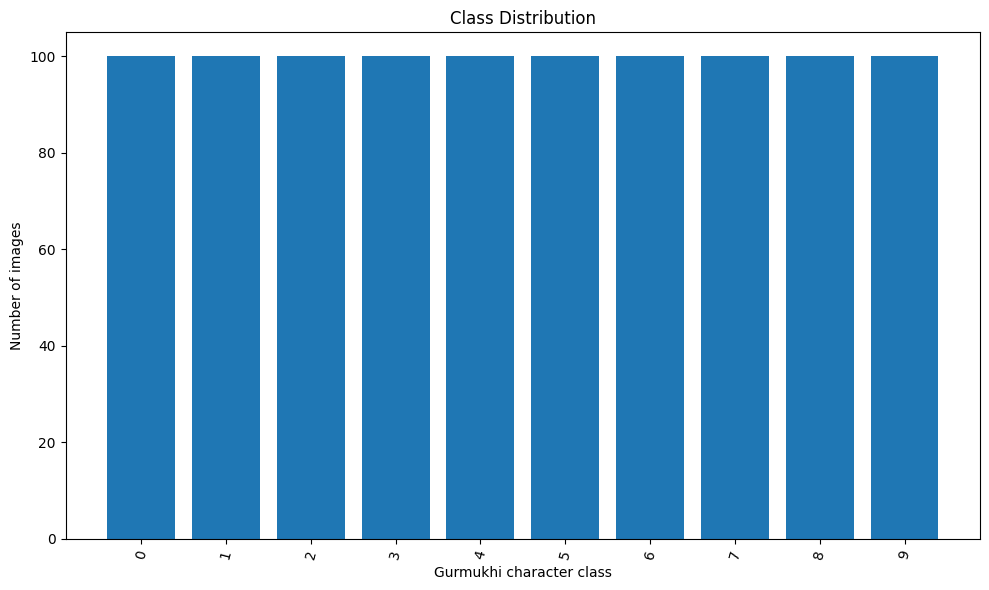

In [9]:
summary = (
    df.groupby("label")
      .size()
      .reset_index(name="image_count")
      .sort_values("label")
)

display(summary)

plt.figure(figsize=(max(10, len(summary)*0.35), 6))
plt.bar(summary["label"].astype(str), summary["image_count"])
plt.xlabel("Gurmukhi character class")
plt.ylabel("Number of images")
plt.title("Class Distribution")
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig(OUT/"class_distribution.png", dpi=180)
plt.show()


## Step 6 — Display sample handwritten characters

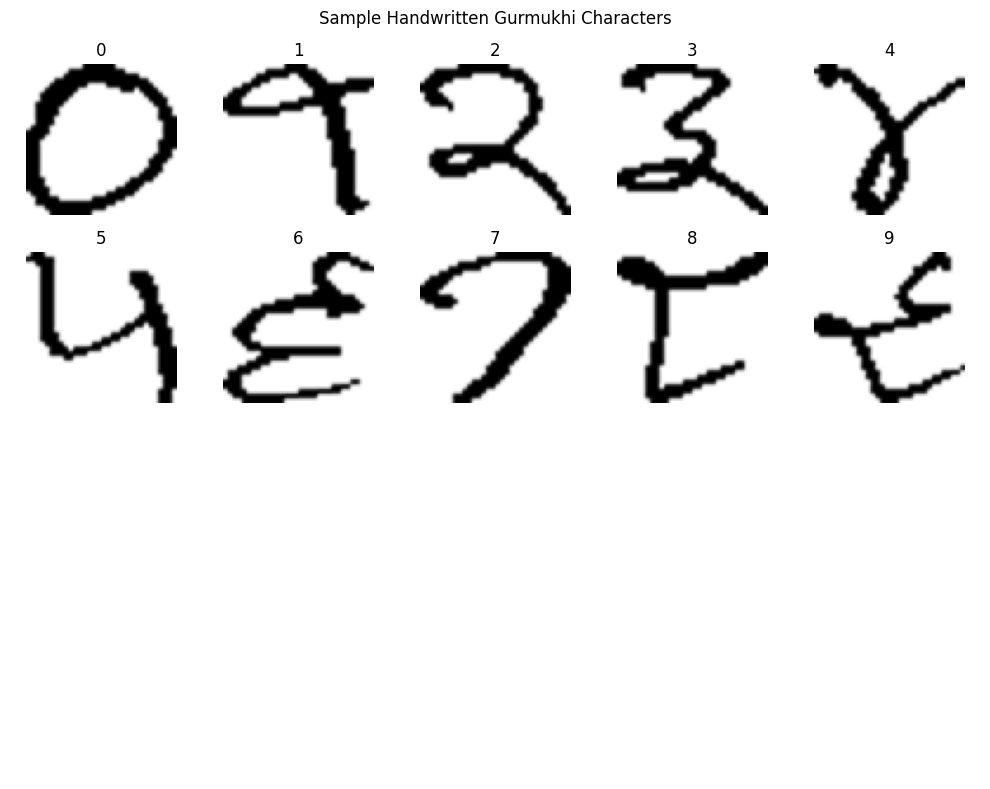

In [10]:
def preprocess_image(path):
    image = Image.open(path).convert("L")
    image = ImageOps.autocontrast(image)
    image = image.resize((64, 64))
    return np.asarray(image, dtype=np.float32) / 255.0

sample_df = df.groupby("label", group_keys=False).head(1).head(20)

fig, axes = plt.subplots(4, 5, figsize=(10, 8))
axes = axes.ravel()

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    ax.imshow(preprocess_image(row["path"]), cmap="gray")
    ax.set_title(row["label"])
    ax.axis("off")

plt.suptitle("Sample Handwritten Gurmukhi Characters")
plt.tight_layout()
plt.savefig(OUT/"sample_grid.png", dpi=180)
plt.show()


## Step 7 — Image preprocessing

Each image is:
1. converted to grayscale,
2. contrast-normalized,
3. resized to 64×64 pixels,
4. normalized to the range 0–1.

This gives the classifier a consistent input representation.


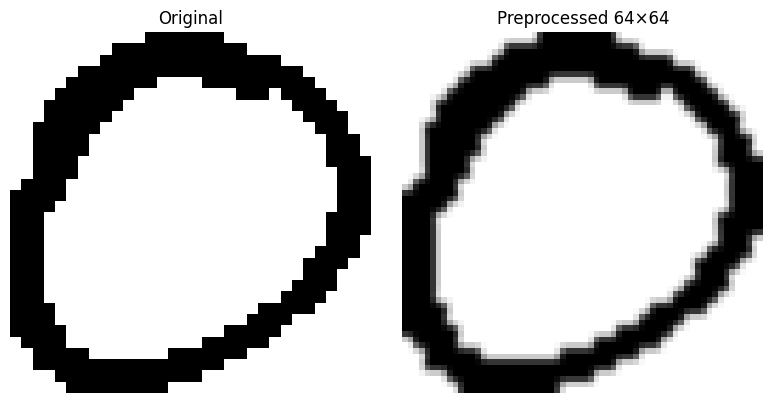

In [11]:
IMAGE_SIZE = (64, 64)

# Show one image before and after preprocessing
example_path = df.iloc[0]["path"]
original = Image.open(example_path)
processed = preprocess_image(example_path)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(original, cmap="gray")
ax[0].set_title("Original")
ax[0].axis("off")
ax[1].imshow(processed, cmap="gray")
ax[1].set_title("Preprocessed 64×64")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## Step 8 — Feature preparation

Two classical image-feature types are used:

**HOG (Histogram of Oriented Gradients):** captures local stroke and edge direction.

**Zoning:** divides the 64×64 image into a 4×4 grid and calculates the mean pixel intensity in each zone.

The two feature vectors are concatenated before Naive Bayes training.


In [12]:
def zoning_features(image, zones=(4, 4)):
    h, w = image.shape
    rows, cols = zones
    values = []
    for r in range(rows):
        for c in range(cols):
            y0, y1 = r*h//rows, (r+1)*h//rows
            x0, x1 = c*w//cols, (c+1)*w//cols
            values.append(float(image[y0:y1, x0:x1].mean()))
    return np.asarray(values, dtype=np.float32)

def extract_features(path):
    image = preprocess_image(path)

    hog_features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )

    zone_features = zoning_features(image)
    return np.concatenate([hog_features, zone_features]).astype(np.float32)

def build_feature_matrix(paths):
    return np.vstack([extract_features(p) for p in paths])

print("Feature functions ready.")
print("Example feature length:", len(extract_features(df.iloc[0]["path"])))


Feature functions ready.
Example feature length: 1780


## Step 9 — Train/test split

An 80:20 stratified split is used so that each character class is represented in both training and testing data.


In [13]:
X_paths = df["path"].tolist()
y = df["label"].tolist()

train_paths, test_paths, y_train, y_test = train_test_split(
    X_paths,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training images:", len(train_paths))
print("Testing images :", len(test_paths))


Training images: 800
Testing images : 200


## Step 10 — Extract training and testing features

In [14]:
print("Extracting training features...")
X_train = build_feature_matrix(train_paths)

print("Extracting testing features...")
X_test = build_feature_matrix(test_paths)

print("Training feature matrix:", X_train.shape)
print("Testing feature matrix :", X_test.shape)


Extracting training features...
Extracting testing features...
Training feature matrix: (800, 1780)
Testing feature matrix : (200, 1780)


## Step 11 — Train Gaussian Naive Bayes

Gaussian Naive Bayes models the probability of the extracted features for each class and combines these probabilities to select the most likely Gurmukhi character.


In [15]:
model = GaussianNB()
model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")
print("Classes:", len(model.classes_))


Naive Bayes model trained successfully.
Classes: 10


## Step 12 — Evaluate the classifier

In [16]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="macro", zero_division=0
)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

display(metrics.style.format({"Score": "{:.4f}"}))

print("\nDetailed classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

metrics.to_csv(OUT/"metrics_summary.csv", index=False)
with open(OUT/"metrics.json", "w", encoding="utf-8") as f:
    json.dump({
        "accuracy": float(accuracy),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1)
    }, f, indent=2, ensure_ascii=False)


,Metric,Score
0,Accuracy,0.9000
1,Macro Precision,0.9150
2,Macro Recall,0.9000
3,Macro F1-score,0.9007



Detailed classification report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        20
           1       0.88      0.70      0.78        20
           2       0.94      0.80      0.86        20
           3       0.73      0.95      0.83        20
           4       0.83      1.00      0.91        20
           5       1.00      1.00      1.00        20
           6       0.77      1.00      0.87        20
           7       1.00      0.85      0.92        20
           8       1.00      0.95      0.97        20
           9       1.00      0.85      0.92        20

    accuracy                           0.90       200
   macro avg       0.91      0.90      0.90       200
weighted avg       0.91      0.90      0.90       200



## Step 13 — Confusion matrix

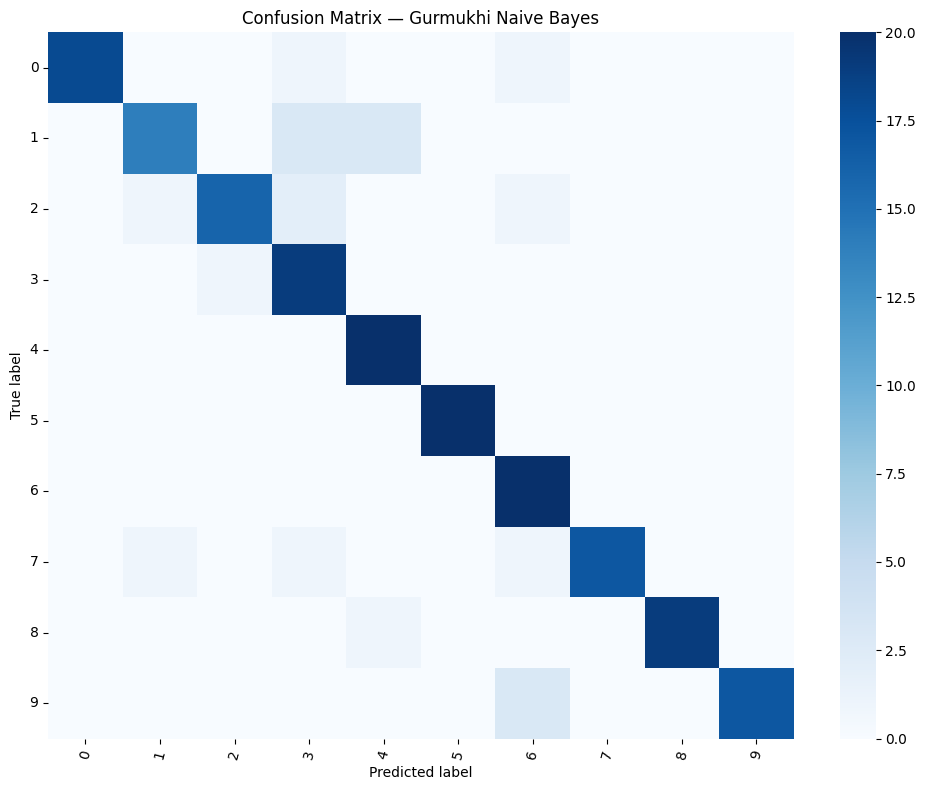

In [17]:
labels = sorted(set(y_test) | set(y_pred))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(max(10, len(labels)*0.35), max(8, len(labels)*0.35)))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — Gurmukhi Naive Bayes")
plt.xticks(rotation=75)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUT/"confusion_matrix.png", dpi=180)
plt.show()


## Step 14 — Inspect some predictions

In [18]:
preview = pd.DataFrame({
    "image": test_paths[:30],
    "actual": y_test[:30],
    "predicted": y_pred[:30]
})
preview["correct"] = preview["actual"] == preview["predicted"]
display(preview)


,image,actual,predicted,correct
0,/content/data/raw/gurmukhi/1/train_74_76.bmp,1,1,True
1,/content/data/raw/gurmukhi/0/train_93_93.bmp,0,0,True
2,/content/data/raw/gurmukhi/6/train_73_75.bmp,6,6,True
3,/content/data/raw/gurmukhi/5/train_41_46.bmp,5,5,True
4,/content/data/raw/gurmukhi/0/train_29_35.bmp,0,0,True
5,/content/data/raw/gurmukhi/2/train_49_53.bmp,2,2,True
6,/content/data/raw/gurmukhi/9/train_5_13.bmp,9,9,True
7,/content/data/raw/gurmukhi/2/train_59_62.bmp,2,3,False
8,/content/data/raw/gurmukhi/4/train_87_88.bmp,4,4,True
9,/content/data/raw/gurmukhi/5/train_61_64.bmp,5,5,True


## Step 15 — Classify an unseen handwritten Gurmukhi character

Upload an image that was **not used during training/testing**. The model will return its top predictions and probabilities.


Upload ONE new handwritten Gurmukhi numeral image.
The image should NOT be from the training/testing dataset.


Saving WhatsApp Image 2026-09-18 at 3.05.38 PM.jpeg to WhatsApp Image 2026-09-18 at 3.05.38 PM.jpeg

UNSEEN SAMPLE CLASSIFICATION
Uploaded image: WhatsApp Image 2026-09-18 at 3.05.38 PM.jpeg
Predicted Gurmukhi numeral: 3

Prediction probabilities:
Class 3: 1.0000 (100.00%)
Class 0: 0.0000 (0.00%)
Class 1: 0.0000 (0.00%)
Class 2: 0.0000 (0.00%)
Class 4: 0.0000 (0.00%)
Class 5: 0.0000 (0.00%)
Class 6: 0.0000 (0.00%)
Class 7: 0.0000 (0.00%)
Class 8: 0.0000 (0.00%)
Class 9: 0.0000 (0.00%)


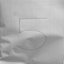

In [23]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
from skimage.feature import hog

print("Upload ONE new handwritten Gurmukhi numeral image.")
print("The image should NOT be from the training/testing dataset.")

uploaded = files.upload()

if not uploaded:
    raise ValueError("No image was uploaded.")

image_path = list(uploaded.keys())[0]

# Load image
img = Image.open(image_path).convert("L")

# Preprocessing — same basic preprocessing used for the project
img = ImageOps.autocontrast(img)
img = img.resize((64, 64))

img_array = np.asarray(img, dtype=np.float32) / 255.0

# HOG feature extraction
hog_features = hog(
    img_array,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys"
)

# 4 × 4 zoning features
zone_features = []

for i in range(4):
    for j in range(4):
        zone = img_array[
            i * 16:(i + 1) * 16,
            j * 16:(j + 1) * 16
        ]
        zone_features.append(np.mean(zone))

# Combine features
features = np.concatenate([
    hog_features,
    np.array(zone_features)
])

X_unseen = features.reshape(1, -1)

# Predict using trained Gaussian Naive Bayes model
prediction = model.predict(X_unseen)[0]

print("\n======================================")
print("UNSEEN SAMPLE CLASSIFICATION")
print("======================================")
print("Uploaded image:", image_path)
print("Predicted Gurmukhi numeral:", prediction)

# Show probability for every class
probabilities = model.predict_proba(X_unseen)[0]
classes = model.classes_

print("\nPrediction probabilities:")

for cls, prob in sorted(
    zip(classes, probabilities),
    key=lambda x: x[1],
    reverse=True
):
    print(f"Class {cls}: {prob:.4f} ({prob * 100:.2f}%)")

# Display uploaded image
display(img)


## Step 16 — Save the trained model

In [24]:
import joblib

MODEL_PATH = MODEL_DIR / "gurmukhi_naive_bayes.joblib"

joblib.dump({
    "model": model,
    "labels": list(model.classes_),
    "feature_description": "HOG + 4x4 zoning"
}, MODEL_PATH)

print("Saved model:", MODEL_PATH)


Saved model: /content/gurmukhi_project/models/gurmukhi_naive_bayes.joblib


## Step 17 — Download project outputs

These files can be used in the project report:
- class distribution graph
- sample grid
- confusion matrix
- metrics summary
- classification report
- JSON metrics
- trained model


In [25]:
print("Output files:")
for p in sorted(OUT.iterdir()):
    print("-", p.name)
print("-", MODEL_PATH.name)


Output files:
- class_distribution.png
- confusion_matrix.png
- metrics.json
- metrics_summary.csv
- sample_grid.png
- gurmukhi_naive_bayes.joblib


In [26]:
import shutil

shutil.make_archive(
    "/content/Gurmukhi_Naive_Bayes_Project",
    "zip",
    "/content/gurmukhi_project"
)

print("Project ZIP created successfully.")

Project ZIP created successfully.


In [27]:
from google.colab import files

files.download("/content/Gurmukhi_Naive_Bayes_Project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final conclusion

The project implements a complete classical machine-learning pipeline for handwritten Gurmukhi character classification. The system performs dataset exploration, image preprocessing, HOG and zoning feature preparation, Gaussian Naive Bayes training, unseen-sample prediction, and evaluation using accuracy, precision, recall, F1-score and a confusion matrix.

**Important:** use the numerical results generated by your actual run in the final report. Do not copy example accuracy values from other papers or projects.
